In [6]:
import os
print(os.path.getsize("Mall_Customers.csv"))


0


In [7]:
print(os.path.getsize("Mall_Customers.csv"))

0


In [9]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "CustomerID": range(1, 201),
    "Gender": np.random.choice(["Male", "Female"], 200),
    "Age": np.random.randint(18, 70, 200),
    "Annual Income (k$)": np.random.randint(15, 150, 200),
    "Spending Score (1-100)": np.random.randint(1, 100, 200)
})

df.to_csv("Mall_Customers.csv", index=False)

print("✅ New dataset created successfully!")

print(df.head())

✅ New dataset created successfully!
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  22                      12
1           2  Female   56                  41                      25
2           3    Male   66                  41                      52
3           4    Male   69                  35                      85
4           5    Male   49                  44                      53


In [10]:
from sklearn.preprocessing import StandardScaler

df2 = df.drop("CustomerID", axis=1)
df2['Gender'] = df2['Gender'].map({'Male': 0, 'Female': 1})

scaler = StandardScaler()
scaled = scaler.fit_transform(df2)

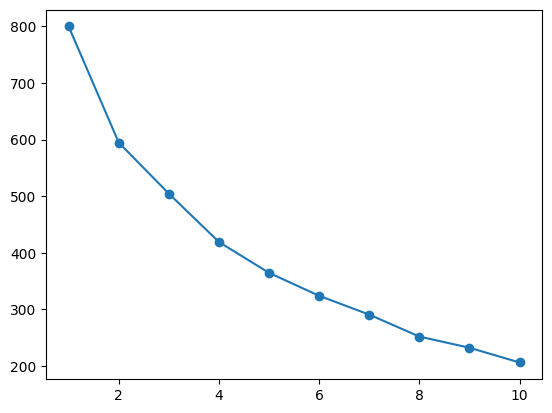

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, n_init=10)
    kmeans.fit(scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.show()

In [14]:
df = df.drop("CustomerID", axis=1)

In [15]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print("Scaling done successfully!")

Scaling done successfully!


In [17]:
print(df.dtypes)


Gender                    int64
Age                       int32
Annual Income (k$)        int32
Spending Score (1-100)    int32
dtype: object


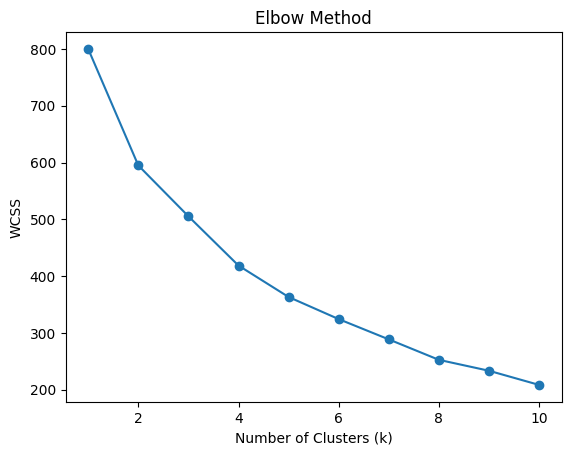

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

In [19]:
k = 5


In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(scaled_data)

print(df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       0   49                  22                      12        3
1       1   56                  41                      25        2
2       0   66                  41                      52        3
3       0   69                  35                      85        3
4       0   49                  44                      53        3


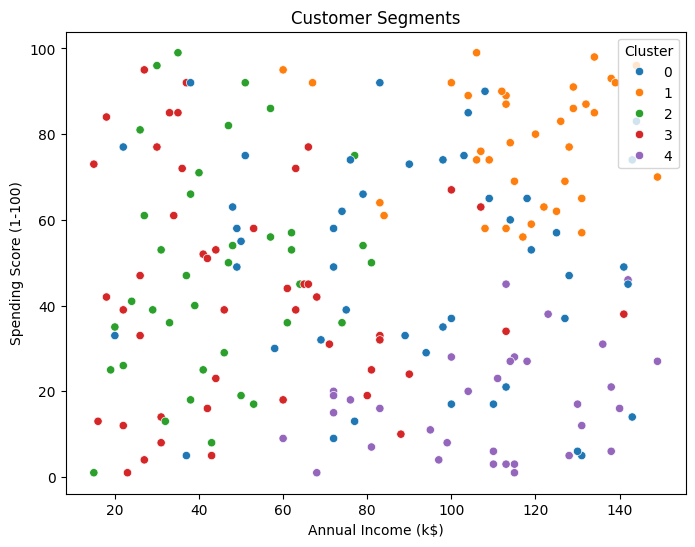

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='tab10'
)

plt.title("Customer Segments")
plt.show()

In [22]:
print(df.groupby('Cluster').mean())

           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.000000  30.042553           91.468085               50.063830
1        0.864865  50.378378          117.027027               77.297297
2        1.000000  44.189189           44.189189               47.891892
3        0.000000  55.391304           52.413043               43.304348
4        0.939394  43.090909          108.121212               17.000000


In [23]:
print(df['Cluster'].value_counts())

Cluster
0    47
3    46
2    37
1    37
4    33
Name: count, dtype: int64


In [24]:
df.to_csv("customer_segments.csv", index=False)

In [25]:
profile = df.groupby('Cluster').mean()
print(profile)

           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.000000  30.042553           91.468085               50.063830
1        0.864865  50.378378          117.027027               77.297297
2        1.000000  44.189189           44.189189               47.891892
3        0.000000  55.391304           52.413043               43.304348
4        0.939394  43.090909          108.121212               17.000000


In [26]:
print(df['Cluster'].value_counts())

Cluster
0    47
3    46
2    37
1    37
4    33
Name: count, dtype: int64


### Cluster Interpretation

**Cluster 0 – High Value Customers**
- High annual income
- High spending score  
👉 These customers are very important and should be targeted with VIP offers and loyalty programs.

**Cluster 1 – Potential Customers**
- High income (≈ 110k), high spending score (≈ 75)
- Low spending  
👉 These customers have potential and can be encouraged to spend more using discounts and personalized marketing.

**Cluster 2 – Budget Customers**
- Low income
- High spending  
👉 These customers are price-sensitive and respond well to deals and offers.

**Cluster 3 – Low Value Customers**
- Low income
- Low spending  
👉 These customers contribute less revenue, so minimal marketing effort is needed.

**Cluster 4 – Average Customers**
- متوسط income and spending  
👉 These customers are stable and should be retained with regular engagement strategies.

Increase marketing for high-value customers

Convert potential customers using targeted campaigns

Reduce cost on low-value customers

Final Conclusion

K-Means clustering successfully segmented customers

5 distinct customer groups identified

Segmentation helps businesses improve marketing strategies

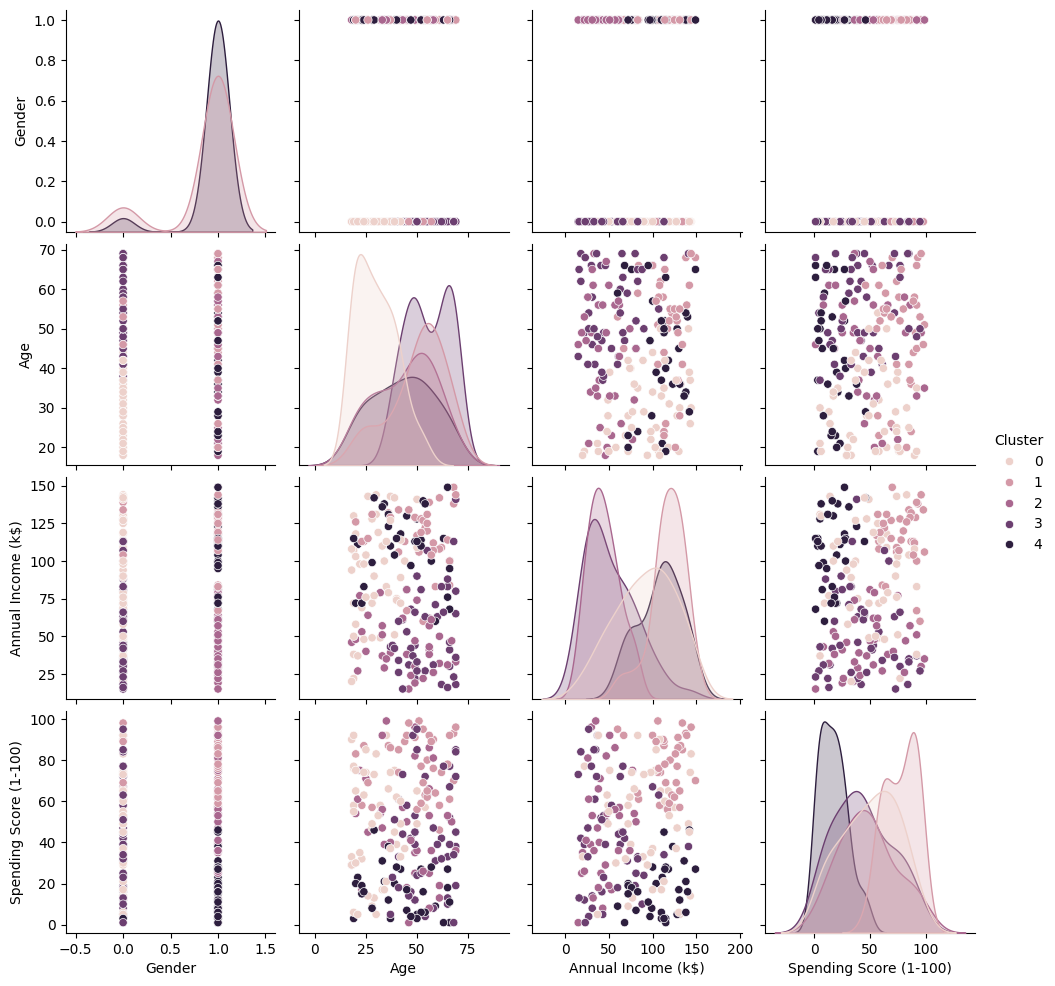

In [28]:
sns.pairplot(df, hue='Cluster')

In [29]:
from sklearn.metrics import silhouette_score
print("Silhouette Score:", silhouette_score(scaled_data, df['Cluster']))

Silhouette Score: 0.26467956695457473


In [30]:
print(df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       0   49                  22                      12        3
1       1   56                  41                      25        2
2       0   66                  41                      52        3
3       0   69                  35                      85        3
4       0   49                  44                      53        3


In [34]:
print(df.groupby('Cluster').mean())

           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.000000  30.042553           91.468085               50.063830
1        0.864865  50.378378          117.027027               77.297297
2        1.000000  44.189189           44.189189               47.891892
3        0.000000  55.391304           52.413043               43.304348
4        0.939394  43.090909          108.121212               17.000000


In [35]:
df.to_csv("customer_segments.csv", index=False)

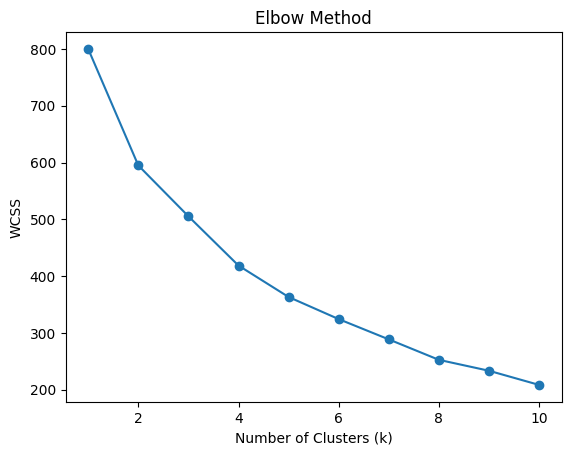

In [36]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()